# 01 — Exploratory Data Analysis · Bank Marketing

Stage 1 EDA for the Adaptive Experimentation Platform (Datathon 7MLET, Grupo 65).

Goals: understand the factual reference base, confirm the **no-leakage** decision
(drop `duration`), and surface the structure the synthetic experimentation layer
(Stage 2) will build on. The raw CSV is git-ignored; run `aep data build` first.

> All charts use the **raw** frame for illustration and the **processed**
> (leakage-free) frame for anything that feeds modelling.

In [1]:
import sys
from pathlib import Path

# Make the src/ package importable when running the notebook in-place.
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from aep.data.loader import TARGET_ENCODED, load_raw, load_processed
from aep.data.schema import COLUMNS, ColumnKind

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
raw = load_raw(verify=False)
proc = load_processed()
print('raw     :', raw.shape)
print('processed:', proc.shape)
raw.head()

raw     : (41188, 21)
processed: (41188, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Target balance

The positive class (subscribed a term deposit) is rare (~11%). This imbalance
shapes evaluation later: raw accuracy is misleading; we report balanced metrics
and per-segment exposure.

subscription rate: 11.27%


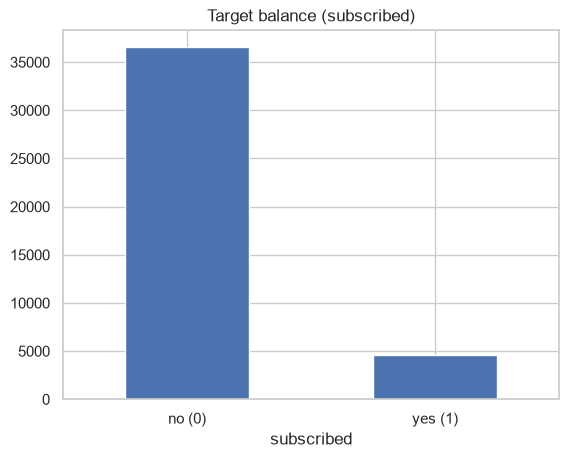

In [3]:
rate = proc[TARGET_ENCODED].mean()
print(f'subscription rate: {rate:.2%}')
ax = proc[TARGET_ENCODED].value_counts().sort_index().plot.bar()
ax.set_xticklabels(['no (0)', 'yes (1)'], rotation=0)
ax.set_title('Target balance (subscribed)')
plt.show()

## Why `duration` is dropped (leakage illustration)

`duration` is the call length in seconds — only known **after** the call. It
almost perfectly separates the classes, so keeping it would leak the outcome.

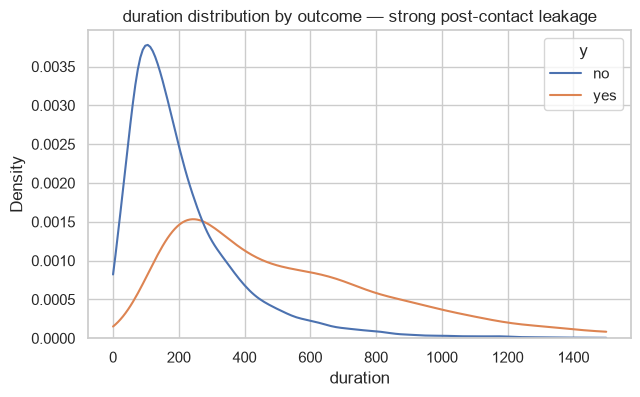

y
no     163.5
yes    449.0
Name: duration, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=raw, x='duration', hue='y', common_norm=False, clip=(0, 1500), ax=ax)
ax.set_title('duration distribution by outcome — strong post-contact leakage')
plt.show()
print(raw.groupby('y')['duration'].median())

## Numeric features (leakage-free) distributions

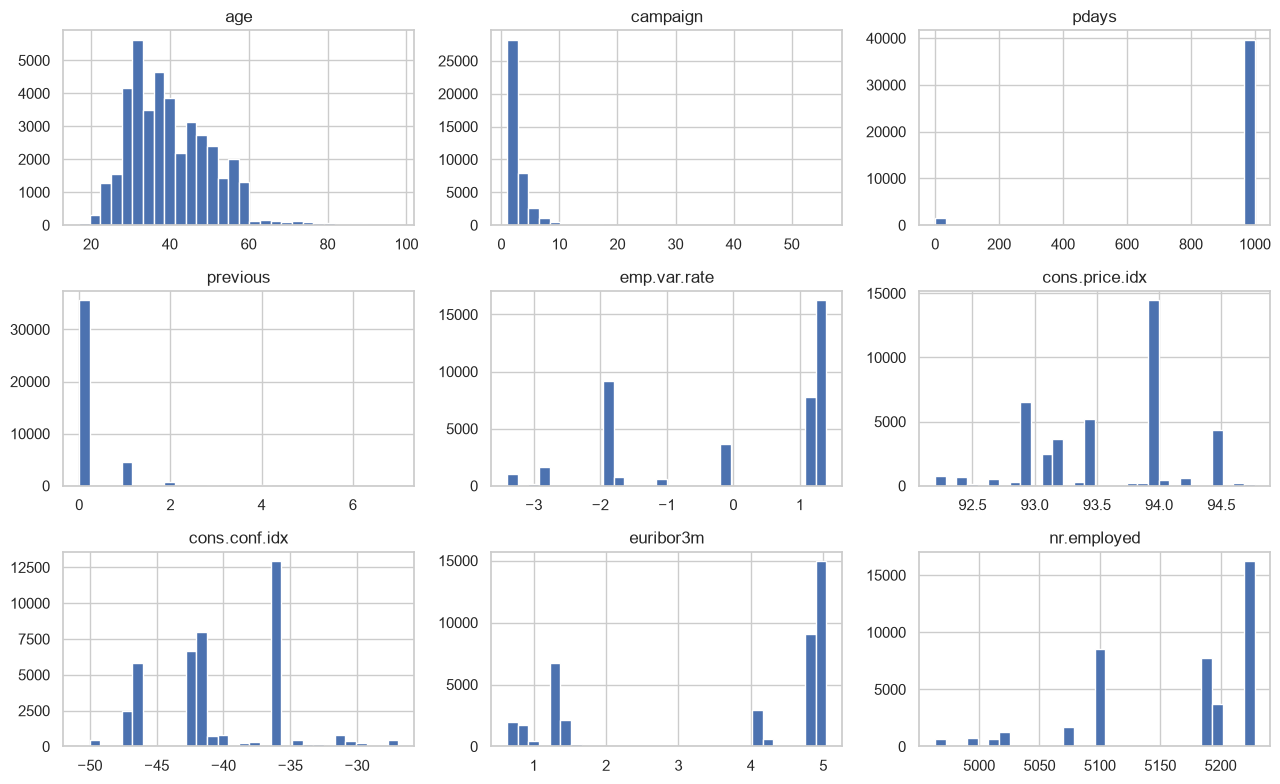

In [5]:
numeric = [c.name for c in COLUMNS if c.kind is ColumnKind.NUMERIC and c.name != 'duration']
raw[numeric].hist(figsize=(13, 8), bins=30)
plt.tight_layout()
plt.show()

## Subscription rate by key categorical segments

These segment-level rates motivate a **contextual** policy: conversion varies a
lot by job, contact channel, previous outcome and month.

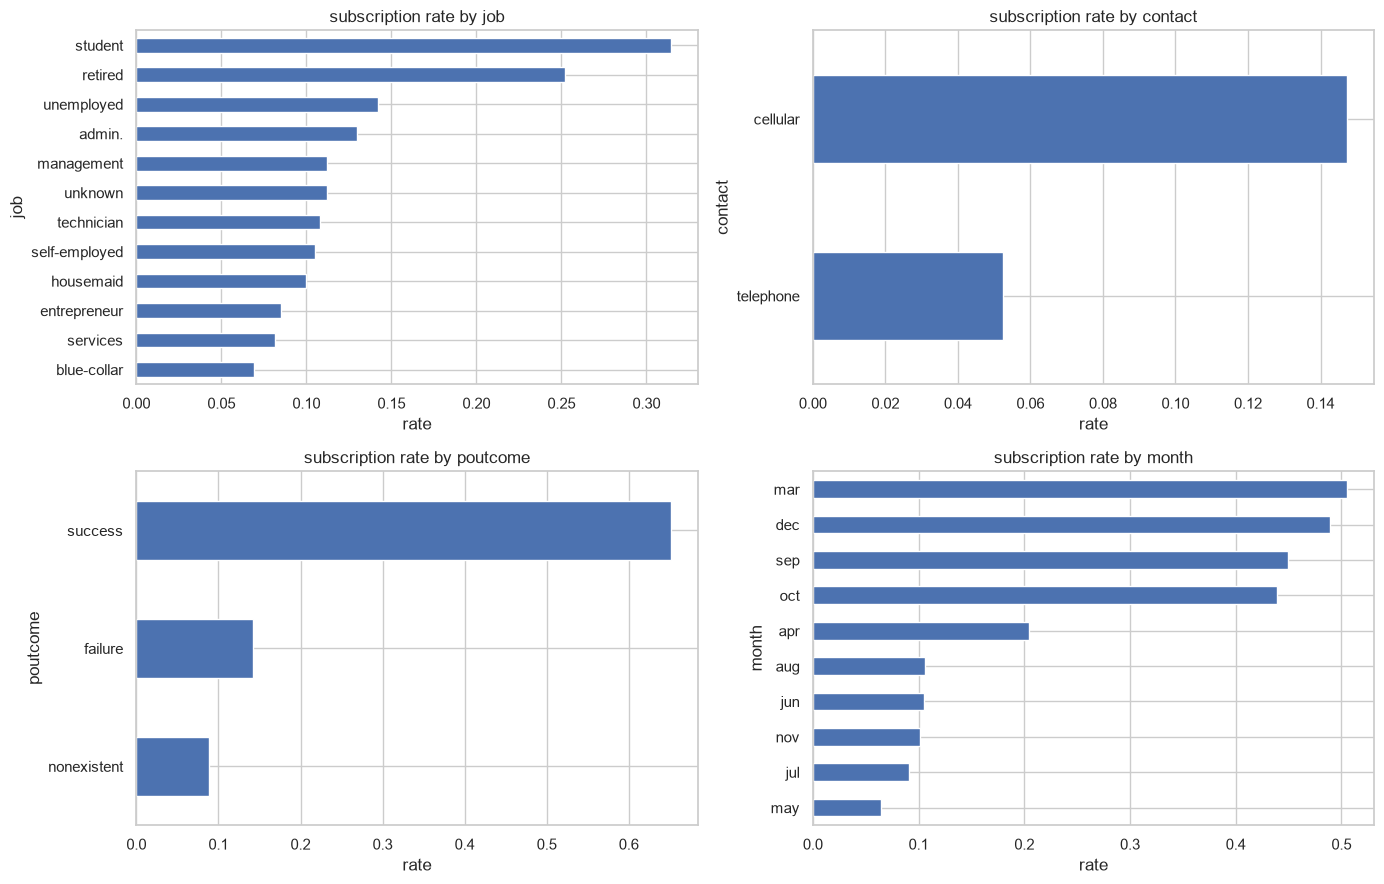

In [6]:
tmp = raw.copy()
tmp['subscribed'] = (tmp['y'] == 'yes').astype(int)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), ['job', 'contact', 'poutcome', 'month']):
    (tmp.groupby(col)['subscribed'].mean().sort_values()
        .plot.barh(ax=ax, title=f'subscription rate by {col}'))
    ax.set_xlabel('rate')
plt.tight_layout()
plt.show()

## Correlation among leakage-free numeric features

The macro indicators (`emp.var.rate`, `euribor3m`, `nr.employed`) are strongly
correlated — relevant when the contextual bandit uses them as context features.

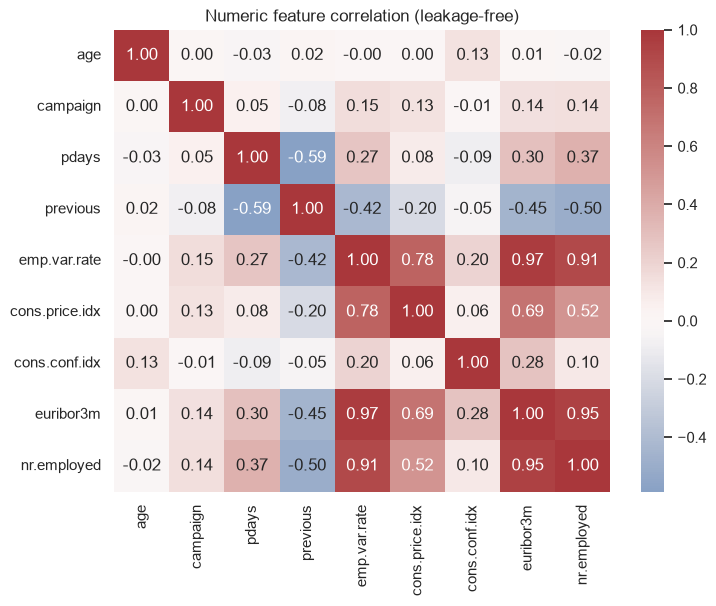

In [7]:
corr = raw[numeric].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Numeric feature correlation (leakage-free)')
plt.show()

## Takeaways for the bandit design (Stage 2-3)

- **Imbalanced reward** (~11% base conversion) → priors/cold-start matter.
- **Strong segment heterogeneity** (job, channel, previous outcome, month) →
  justifies a **contextual** bandit (LinUCB / neural) over context-free policies.
- **`pdays = 999`** dominates (96%) → engineer a `was_previously_contacted` flag.
- **Macro indicators** are collinear → keep but be mindful in linear models.
- **`duration` dropped** — leakage confirmed visually.